# Lesson 4: Flexible Noise Curves — `FlexibleNoiseComparisonModel` and `FlexibleNoiseRiskModel`

## Motivation: when does Weber's law hold?

The log-space models from lessons 2–3 (MCM, PMCM) assume that the internal
representation of magnitude follows Weber's law: noise scales proportionally
with magnitude, $\sigma(n) \propto n$.  This is a good description for **perceptual**
stimuli such as dot arrays, where numerosity is read off directly from visual input.

But what about **symbolic** numerals?  When participants see the digit \u201c47\u201d, the
noise on their internal representation need not scale the same way.  The
**Flexible Noise models** let the data reveal the actual noise-vs-magnitude curve
rather than assuming it in advance.

The key difference from the log-space models:

| Model | Evidence space | Noise $\nu(n)$ | Weber's law |
|-------|---------------|----------------|-----------------|
| MCM / PMCM | log $n$ | fixed scalar $\nu_\text{log}$ | $\sigma_\text{nat}(n) = \nu_\text{log}\!\times\!n$ (linear) |
| **AffineNoise** | $n$ (natural) | $\text{softplus}(\beta_0 + \beta_1 \hat{n})$ | linear $\Leftrightarrow \beta_0 = 0$ |
| **FlexNoise** | $n$ (natural) | B-spline curve | linear $\nu(n) \propto n$ |

All three natural-space models share the same core computation:

$$\nu_k(n) = \text{softplus}\!\left(\sum_{j} \beta_{k,j}\,\phi_j(n)\right)$$

What changes between them is the **basis** $\phi_j(n)$:
- **FlexNoise** uses B-spline basis functions (default 5 per option) — very flexible
  but potentially over-parameterised.
- **AffineNoise** uses a simple two-element basis $[\,1,\; \hat n\,]$ where
  $\hat n = (n - n_\min)/(n_\max - n_\min)$.  This gives an intercept (baseline noise)
  plus a linear term (Weber-like scaling): $\nu(n) \approx a + b\,n$.

The affine model sits neatly in the complexity hierarchy:

$$\text{MCM (2 noise params)} \quad\subset\quad \text{AffineNoise (4 noise params)}
\quad\subset\quad \text{FlexNoise (10 noise params)}$$

If the FlexNoise ELPD advantage over MCM is driven by a non-zero noise floor rather than
genuine nonlinearity, the AffineNoise model should capture most of the improvement with
far fewer parameters.

- **Linear** $\nu(n) \propto n$ $\Rightarrow$ scale invariance / Weber's law
- **Flat** $\nu(n)$ $\Rightarrow$ constant absolute noise (sub-Weber at large $n$)
- **Affine** $\nu(n) = a + bn$ $\Rightarrow$ noise floor + Weber scaling
- **Super-linear** $\nu(n)$ $\Rightarrow$ worse precision at large $n$ (super-Weber)

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import arviz as az
from bauer.utils.data import load_garcia2022, load_dehollander2024
from bauer.models import (MagnitudeComparisonModel, FlexibleNoiseComparisonModel,
                           RiskModel, FlexibleNoiseRiskModel)

# ── AffineNoise: a simple alternative between MCM and FlexNoise ──────────────
# The key idea: FlexibleNoiseComparisonModel uses B-spline basis functions to
# parameterise ν(n).  If the deviation from Weber's law is just a constant noise
# floor (ν(n) = a + b·n instead of ν(n) = b·n), we can capture that with a
# two-element basis [1, n̂] instead of 5 B-spline bases.
#
# Implementation: subclass FlexibleNoiseComparisonModel, override make_dm()
# to return an affine design matrix, and fix polynomial_order=2.

class AffineNoiseComparisonModel(FlexibleNoiseComparisonModel):
    # Magnitude-comparison model with affine noise: v(n) = softplus(b0 + b1*n_hat)
    def __init__(self, paradigm, fit_seperate_evidence_sd=True,
                 fit_prior=False, memory_model='independent'):
        super().__init__(paradigm, fit_seperate_evidence_sd=fit_seperate_evidence_sd,
                         fit_prior=fit_prior, polynomial_order=2,
                         memory_model=memory_model)

    def make_dm(self, x, variable='n1_evidence_sd'):
        # Override: [1, n_hat] basis instead of B-splines
        min_n = self.paradigm[['n1', 'n2']].min().min()
        max_n = self.paradigm[['n1', 'n2']].max().max()
        x_norm = (np.asarray(x, dtype=float) - min_n) / (max_n - min_n)
        return np.column_stack([np.ones_like(x_norm), x_norm])


class AffineNoiseRiskModel(FlexibleNoiseRiskModel):
    # Risky-choice model with affine noise: v(n) = softplus(b0 + b1*n_hat)
    def __init__(self, paradigm, prior_estimate='full',
                 fit_seperate_evidence_sd=True, memory_model='independent'):
        super().__init__(paradigm, prior_estimate=prior_estimate,
                         fit_seperate_evidence_sd=fit_seperate_evidence_sd,
                         polynomial_order=2, memory_model=memory_model)

    def make_dm(self, x, variable='n1_evidence_sd'):
        # Override: [1, n_hat] basis instead of B-splines
        min_n = self.paradigm[['n1', 'n2']].min().min()
        max_n = self.paradigm[['n1', 'n2']].max().max()
        x_norm = (np.asarray(x, dtype=float) - min_n) / (max_n - min_n)
        return np.column_stack([np.ones_like(x_norm), x_norm])

# Garcia et al. (2022) — dot-array magnitude comparison
df_mag = load_garcia2022(task='magnitude')
print(f"Garcia magnitude  |  subjects: {df_mag.index.get_level_values('subject').nunique()},  "
      f"trials: {len(df_mag)}")

# de Hollander et al. (2024, bioRxiv) — Arabic-numeral gambles
df_sym = load_dehollander2024(task='symbolic')
print(f"Arabic numerals   |  subjects: {df_sym.index.get_level_values('subject').nunique()},  "
      f"trials: {len(df_sym)}")

Garcia magnitude  |  subjects: 64,  trials: 13824


Arabic numerals   |  subjects: 58,  trials: 14722


## Illustrating flexible noise curves

The left panel shows the three canonical noise-vs-magnitude shapes.
The right panel shows the **key signature of Weber's law**: when noise is
linear ($\nu \propto n$), psychometric curves plotted against the *relative*
difference $(n_2 - n_1)/n_1$ collapse onto a single curve regardless of the
reference magnitude $n_1$ — scale invariance.  Flat or super-linear noise
breaks this collapse.

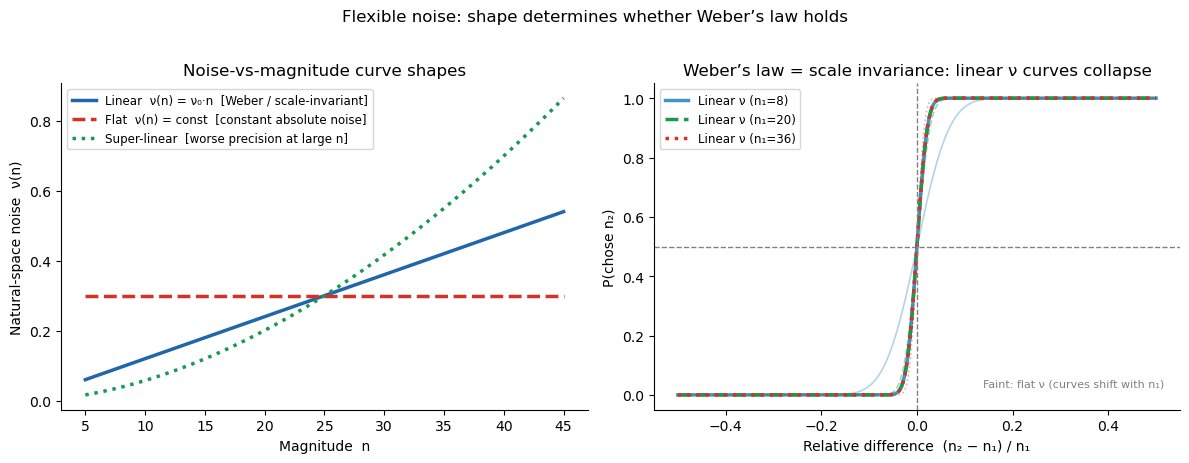

In [2]:
from scipy.stats import norm as scipy_norm

n_vals   = np.linspace(5, 45, 200)
nu0      = 0.30          # noise level at mean magnitude
rel_diffs = np.linspace(-0.5, 0.5, 300)   # (n2 - n1) / n1

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Left: noise curves in natural space
ax = axes[0]
noise_curves = [
    ('Linear  ν(n) = ν₀·n  [Weber / scale-invariant]',
     nu0 * n_vals / n_vals.mean(),        '#2166ac', '-'),
    ('Flat  ν(n) = const  [constant absolute noise]',
     np.full_like(n_vals, nu0),           '#d73027', '--'),
    ('Super-linear  [worse precision at large n]',
     nu0 * (n_vals / n_vals.mean())**1.8, '#1a9850', ':'),
]
for label, nu_n, c, ls in noise_curves:
    ax.plot(n_vals, nu_n, lw=2.5, color=c, ls=ls, label=label)
ax.set_xlabel('Magnitude  n')
ax.set_ylabel('Natural-space noise  ν(n)')
ax.set_title('Noise-vs-magnitude curve shapes')
ax.legend(fontsize=8.5); sns.despine(ax=ax)

# Right: scale-invariance test — plot P(chose n2) vs (n2-n1)/n1
# With linear noise ν = ν₀×n_ref: P = Φ(rel_diff × n1 / (√2 × ν₀ × n1))
#                                    = Φ(rel_diff / (√2 × ν₀))  — same for all n1!
# With flat noise ν = const: P = Φ(rel_diff × n1 / (√2 × ν_const))  — varies with n1
ax = axes[1]
for n_ref, c, ls in [(8, '#4393c3', '-'), (20, '#1a9850', '--'), (36, '#d73027', ':')]:
    nu_lin  = nu0 * n_ref / n_vals.mean()   # linear noise at n_ref
    nu_flat = nu0                            # flat noise (constant)
    p_lin  = scipy_norm.cdf(rel_diffs * n_ref / (np.sqrt(2) * nu_lin))   # collapses!
    p_flat = scipy_norm.cdf(rel_diffs * n_ref / (np.sqrt(2) * nu_flat))  # shifts by n_ref
    ax.plot(rel_diffs, p_lin,  color=c, lw=2.5, ls=ls, label=f'Linear ν (n₁={n_ref})')
    ax.plot(rel_diffs, p_flat, color=c, lw=1.2, ls=ls, alpha=.4)
ax.axhline(.5, ls='--', c='gray', lw=1)
ax.axvline(0,  ls='--', c='gray', lw=1)
ax.text(0.97, 0.07, 'Faint: flat ν (curves shift with n₁)',
        transform=ax.transAxes, ha='right', fontsize=8, color='gray')
ax.set_xlabel('Relative difference  (n₂ − n₁) / n₁')
ax.set_ylabel('P(chose n₂)')
ax.set_title('Weber’s law = scale invariance: linear ν curves collapse')
ax.legend(fontsize=8.5); sns.despine(ax=ax)

plt.suptitle('Flexible noise: shape determines whether Weber’s law holds',
             fontsize=12, y=1.02)
plt.tight_layout()

## Part A: Dot-array magnitude comparison (Garcia et al. 2022)

Dot arrays are a classic **perceptual** numerosity stimulus where Weber's law is
well-established.  Fitting the Flexible Noise model here serves as a sanity check:
the recovered $\nu(n)$ should be approximately **linear**.  The MCM baseline assumes
log-space noise, which translates to $\sigma_\text{MCM}(n) = \nu_\text{log} \times n$
(a line through the origin) — the same Weber's-law prediction.

In [3]:
# MagnitudeComparisonModel (MCM) — fixed log-space noise (Weber's-law null)
# idata_kwargs passes extra arguments to pymc.sample_posterior_predictive;
# log_likelihood=True stores trial-level log-likelihoods needed for ELPD comparison.
model_mcm = MagnitudeComparisonModel(paradigm=df_mag, fit_seperate_evidence_sd=True)
model_mcm.build_estimation_model(data=df_mag, hierarchical=True)
idata_mcm = model_mcm.sample(draws=200, tune=200, chains=4, progressbar=False,
                              idata_kwargs={'log_likelihood': True})

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [n1_evidence_sd_mu_untransformed, n1_evidence_sd_sd, n1_evidence_sd_offset, n2_evidence_sd_mu_untransformed, n2_evidence_sd_sd, n2_evidence_sd_offset]


Sampling 4 chains for 200 tune and 200 draw iterations (800 + 800 draws total) took 36 seconds.


The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


In [4]:
# FlexibleNoiseComparisonModel — free noise curve fitted to dot arrays
model_flex_mag = FlexibleNoiseComparisonModel(paradigm=df_mag,
                                               fit_seperate_evidence_sd=True,
                                               polynomial_order=5)
model_flex_mag.build_estimation_model(paradigm=df_mag, hierarchical=True)
idata_flex_mag = model_flex_mag.sample(draws=200, tune=200, chains=4, progressbar=False,
                                        idata_kwargs={'log_likelihood': True})

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [n1_evidence_sd_spline1_mu, n1_evidence_sd_spline1_sd, n1_evidence_sd_spline1_offset, n1_evidence_sd_spline2_mu, n1_evidence_sd_spline2_sd, n1_evidence_sd_spline2_offset, n1_evidence_sd_spline3_mu, n1_evidence_sd_spline3_sd, n1_evidence_sd_spline3_offset, n1_evidence_sd_spline4_mu, n1_evidence_sd_spline4_sd, n1_evidence_sd_spline4_offset, n1_evidence_sd_spline5_mu, n1_evidence_sd_spline5_sd, n1_evidence_sd_spline5_offset, n2_evidence_sd_spline1_mu, n2_evidence_sd_spline1_sd, n2_evidence_sd_spline1_offset, n2_evidence_sd_spline2_mu, n2_evidence_sd_spline2_sd, n2_evidence_sd_spline2_offset, n2_evidence_sd_spline3_mu, n2_evidence_sd_spline3_sd, n2_evidence_sd_spline3_offset, n2_evidence_sd_spline4_mu, n2_evidence_sd_spline4_sd, n2_evidence_sd_spline4_offset, n2_evidence_sd_spline5_mu, n2_evidence_sd_spline5_sd, n2_evidence_sd_spline5_offset]


Sampling 4 chains for 200 tune and 200 draw iterations (800 + 800 draws total) took 156 seconds.


The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


In [5]:
# AffineNoiseComparisonModel — intercept + linear noise (defined above)
model_affine_mag = AffineNoiseComparisonModel(paradigm=df_mag,
                                               fit_seperate_evidence_sd=True)
model_affine_mag.build_estimation_model(paradigm=df_mag, hierarchical=True)
idata_affine_mag = model_affine_mag.sample(draws=200, tune=200, chains=4, progressbar=False,
                                            idata_kwargs={'log_likelihood': True})

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [n1_evidence_sd_spline1_mu, n1_evidence_sd_spline1_sd, n1_evidence_sd_spline1_offset, n1_evidence_sd_spline2_mu, n1_evidence_sd_spline2_sd, n1_evidence_sd_spline2_offset, n2_evidence_sd_spline1_mu, n2_evidence_sd_spline1_sd, n2_evidence_sd_spline1_offset, n2_evidence_sd_spline2_mu, n2_evidence_sd_spline2_sd, n2_evidence_sd_spline2_offset]


Sampling 4 chains for 200 tune and 200 draw iterations (800 + 800 draws total) took 92 seconds.


There was 1 divergence after tuning. Increase `target_accept` or reparameterize.


The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


### Posterior noise curves — dot arrays

If Weber's law holds, all three curves should overlap: both the FlexNoise (red) and
AffineNoise (green) should track the MCM reference line $\sigma = \nu_\text{log} \times n$
(dashed blue).  A non-zero intercept in the AffineNoise curve would indicate baseline
noise that does not scale with magnitude.

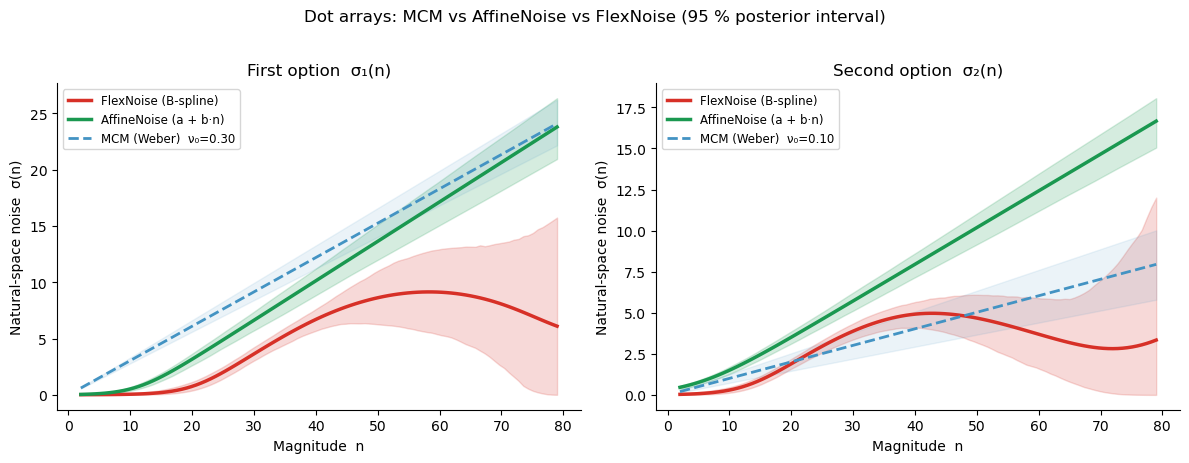

In [6]:
sd_curves_mag = model_flex_mag.get_sd_curve(idata=idata_flex_mag, variable='both',
                                              group=True, data=df_mag.reset_index())
sd_curves_aff = model_affine_mag.get_sd_curve(idata=idata_affine_mag, variable='both',
                                                group=True, data=df_mag.reset_index())
nu1_mcm = idata_mcm.posterior['n1_evidence_sd_mu'].values.ravel()
nu2_mcm = idata_mcm.posterior['n2_evidence_sd_mu'].values.ravel()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
colors = {'flex': '#d73027', 'affine': '#1a9850', 'mcm': '#4393c3'}

for ax, (var_col, nu_mcm_samp, title) in zip(
        axes,
        [('n1_evidence_sd', nu1_mcm, 'First option  σ₁(n)'),
         ('n2_evidence_sd', nu2_mcm, 'Second option  σ₂(n)')]):
    # FlexNoise (B-spline)
    grp = sd_curves_mag.groupby(level='x')[var_col]
    x_vals = grp.mean().index.values
    ax.fill_between(x_vals, grp.quantile(0.025).values, grp.quantile(0.975).values,
                    alpha=.18, color=colors['flex'])
    ax.plot(x_vals, grp.mean().values, lw=2.5, color=colors['flex'], label='FlexNoise (B-spline)')
    # AffineNoise (intercept + linear)
    grp_a = sd_curves_aff.groupby(level='x')[var_col]
    x_a = grp_a.mean().index.values
    ax.fill_between(x_a, grp_a.quantile(0.025).values, grp_a.quantile(0.975).values,
                    alpha=.18, color=colors['affine'])
    ax.plot(x_a, grp_a.mean().values, lw=2.5, color=colors['affine'], label='AffineNoise (a + b·n)')
    # MCM reference (Weber: σ = ν₀ × n)
    nu0 = nu_mcm_samp.mean()
    ax.plot(x_vals, nu0 * x_vals, ls='--', lw=2, color=colors['mcm'],
            label=f'MCM (Weber)  ν₀={nu0:.2f}')
    ax.fill_between(x_vals,
                    np.percentile(nu_mcm_samp, 2.5) * x_vals,
                    np.percentile(nu_mcm_samp, 97.5) * x_vals,
                    alpha=.10, color=colors['mcm'])
    ax.set_xlabel('Magnitude  n')
    ax.set_ylabel('Natural-space noise  σ(n)')
    ax.set_title(title); ax.legend(fontsize=8.5); sns.despine(ax=ax)

plt.suptitle('Dot arrays: MCM vs AffineNoise vs FlexNoise (95 % posterior interval)',
             fontsize=12, y=1.02)
plt.tight_layout()

### Model comparison: MCM vs AffineNoise vs FlexNoise (dot arrays)

**ELPD** (Expected Log Pointwise Predictive Density, computed via PSIS-LOO) formally
tests whether the added flexibility is justified.  The three-way comparison lets us
disentangle two questions:

1. **Is Weber's law (MCM) adequate?** Compare MCM vs AffineNoise.
2. **Is the deviation captured by a simple intercept, or is genuine nonlinearity needed?**
   Compare AffineNoise vs FlexNoise.

If AffineNoise matches FlexNoise on ELPD while beating MCM, the deviation from Weber's
law is well-described by a noise floor — a simple, interpretable parameter.

In [7]:
# ELPD model comparison — dot arrays (3-way)
compare_mag = az.compare({'MCM (Weber)':   idata_mcm,
                           'AffineNoise':   idata_affine_mag,
                           'FlexNoise':     idata_flex_mag})
print(compare_mag[['elpd_loo', 'p_loo', 'elpd_diff', 'dse', 'warning']].to_string())

                elpd_loo       p_loo   elpd_diff        dse  warning
FlexNoise   -3390.563812  246.417456    0.000000   0.000000     True
MCM (Weber) -3481.573198   94.900493   91.009386  26.049270     True
AffineNoise -3573.241605  232.238865  182.677793  22.417787     True


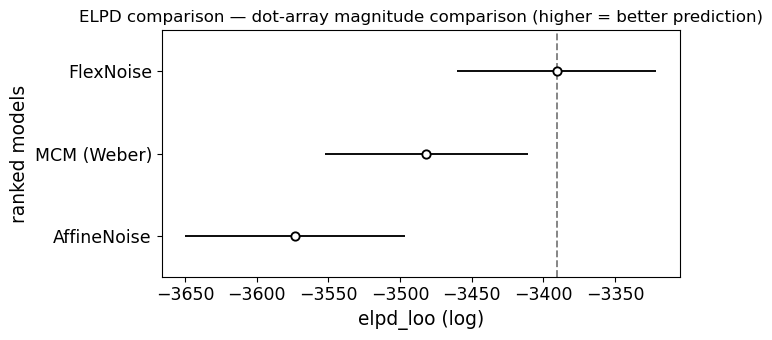

In [8]:
ax = az.plot_compare(compare_mag, figsize=(7, 3.5))
ax.set_title('ELPD comparison — dot-array magnitude comparison (higher = better prediction)')
plt.tight_layout()

In [9]:
# ── Interpret the dot-array ELPD result (3-way) ─────────────────────────────
print("ELPD ranking (dot arrays):")
print(compare_mag[['elpd_loo', 'p_loo', 'elpd_diff', 'dse', 'warning']].to_string())
print()

# Pairwise interpretation
for i in range(1, len(compare_mag)):
    name = compare_mag.index[i]
    diff = compare_mag['elpd_diff'].iloc[i]
    dse  = compare_mag['dse'].iloc[i]
    ratio = abs(diff) / dse if dse > 0 else float('inf')
    winner = compare_mag.index[0]
    verdict = "distinguishable" if ratio > 2 else "NOT distinguishable"
    print(f"  {winner} vs {name}:  DELTA_ELPD = {diff:.1f},  SE = {dse:.1f},  "
          f"|ratio| = {ratio:.1f}  ->  {verdict}")

# Key question: does AffineNoise capture the FlexNoise advantage?
if 'AffineNoise' in compare_mag.index and 'FlexNoise' in compare_mag.index:
    aff_rank = list(compare_mag.index).index('AffineNoise')
    flex_rank = list(compare_mag.index).index('FlexNoise')
    print()
    if abs(aff_rank - flex_rank) <= 1:
        aff_elpd = compare_mag.loc['AffineNoise', 'elpd_loo']
        flex_elpd = compare_mag.loc['FlexNoise', 'elpd_loo']
        print(f"AffineNoise ELPD: {aff_elpd:.1f},  FlexNoise ELPD: {flex_elpd:.1f}")
        if abs(aff_elpd - flex_elpd) < 10:
            print("-> Affine noise captures most of the FlexNoise advantage.")
            print("   The deviation from Weber's law is well-described by a noise floor (a + b*n).")
        else:
            print("-> Affine noise does NOT fully capture the flexible curve's advantage.")
            print("   Genuine nonlinearity in the noise function is needed.")

ELPD ranking (dot arrays):
                elpd_loo       p_loo   elpd_diff        dse  warning
FlexNoise   -3390.563812  246.417456    0.000000   0.000000     True
MCM (Weber) -3481.573198   94.900493   91.009386  26.049270     True
AffineNoise -3573.241605  232.238865  182.677793  22.417787     True

  FlexNoise vs MCM (Weber):  DELTA_ELPD = 91.0,  SE = 26.0,  |ratio| = 3.5  ->  distinguishable
  FlexNoise vs AffineNoise:  DELTA_ELPD = 182.7,  SE = 22.4,  |ratio| = 8.1  ->  distinguishable



## Part B: Arabic-numeral risky choice (de Hollander et al., 2024, bioRxiv)

Arabic numerals are **symbolic**: participants read a printed digit rather than
estimating numerosity from a visual display.  The internal noise on symbolic
number representations need not scale proportionally with magnitude, so we
expect a potential **deviation from the linear Weber's-law prediction**.

We compare `FlexibleNoiseRiskModel` and `AffineNoiseRiskModel` against the
standard `RiskModel` (PMCM) on the same data.

In [10]:
def prep_df(df):
    df = df.reset_index()
    risky_first = df['p1'] == 0.55
    df['log_ratio']     = np.log(
        np.where(risky_first, df['n1'], df['n2']) /
        np.where(risky_first, df['n2'], df['n1']))
    df['chose_risky']   = np.where(risky_first, ~df['choice'], df['choice'])
    df['n_safe']        = np.where(risky_first, df['n2'], df['n1'])
    df['risky_first']   = risky_first
    df['order']         = np.where(risky_first, 'Risky first', 'Safe first')
    df['log_ratio_bin'] = (pd.cut(df['log_ratio'], bins=10)
                             .map(lambda x: x.mid).astype(float))
    df['n_safe_bin']    = pd.qcut(df['n_safe'], q=3,
                                   labels=['Low stakes', 'Mid stakes', 'High stakes'])
    return df

df_sym_p = prep_df(df_sym)

In [11]:
# PMCM (fixed log-space noise) — log_likelihood stored for ELPD comparison
model_pmcm = RiskModel(paradigm=df_sym, prior_estimate='full',
                        fit_seperate_evidence_sd=True)
model_pmcm.build_estimation_model(data=df_sym, hierarchical=True, save_p_choice=True)
idata_pmcm = model_pmcm.sample(draws=200, tune=200, chains=4, progressbar=False,
                                idata_kwargs={'log_likelihood': True})

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [n1_evidence_sd_mu_untransformed, n1_evidence_sd_sd, n1_evidence_sd_offset, n2_evidence_sd_mu_untransformed, n2_evidence_sd_sd, n2_evidence_sd_offset, risky_prior_mu_mu, risky_prior_mu_sd, risky_prior_mu_offset, risky_prior_sd_mu_untransformed, risky_prior_sd_sd, risky_prior_sd_offset, safe_prior_mu_mu, safe_prior_mu_sd, safe_prior_mu_offset, safe_prior_sd_mu_untransformed, safe_prior_sd_sd, safe_prior_sd_offset]


Sampling 4 chains for 200 tune and 200 draw iterations (800 + 800 draws total) took 115 seconds.


The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


In [12]:
# FlexibleNoiseRiskModel — free noise curve on Arabic-numeral data
model_flex = FlexibleNoiseRiskModel(paradigm=df_sym, prior_estimate='full',
                                     fit_seperate_evidence_sd=True, polynomial_order=5)
model_flex.build_estimation_model(paradigm=df_sym, hierarchical=True, save_p_choice=True)
idata_flex = model_flex.sample(draws=200, tune=200, chains=4, progressbar=False,
                                idata_kwargs={'log_likelihood': True})

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [n1_evidence_sd_spline1_mu, n1_evidence_sd_spline1_sd, n1_evidence_sd_spline1_offset, n1_evidence_sd_spline2_mu, n1_evidence_sd_spline2_sd, n1_evidence_sd_spline2_offset, n1_evidence_sd_spline3_mu, n1_evidence_sd_spline3_sd, n1_evidence_sd_spline3_offset, n1_evidence_sd_spline4_mu, n1_evidence_sd_spline4_sd, n1_evidence_sd_spline4_offset, n1_evidence_sd_spline5_mu, n1_evidence_sd_spline5_sd, n1_evidence_sd_spline5_offset, n2_evidence_sd_spline1_mu, n2_evidence_sd_spline1_sd, n2_evidence_sd_spline1_offset, n2_evidence_sd_spline2_mu, n2_evidence_sd_spline2_sd, n2_evidence_sd_spline2_offset, n2_evidence_sd_spline3_mu, n2_evidence_sd_spline3_sd, n2_evidence_sd_spline3_offset, n2_evidence_sd_spline4_mu, n2_evidence_sd_spline4_sd, n2_evidence_sd_spline4_offset, n2_evidence_sd_spline5_mu, n2_evidence_sd_spline5_sd, n2_evidence_sd_spline5_offset, risky_prior_mu_mu, risky_prior_mu_sd, risky_prior_mu_offset, risky_prior_sd_mu_untransformed, risky_prior_sd_sd, risky_prior_sd_offset, safe_pr

Sampling 4 chains for 200 tune and 200 draw iterations (800 + 800 draws total) took 911 seconds.


There were 305 divergences after tuning. Increase `target_accept` or reparameterize.


The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


In [13]:
# AffineNoiseRiskModel — intercept + linear noise for Arabic-numeral gambles
model_affine = AffineNoiseRiskModel(paradigm=df_sym, prior_estimate='full',
                                     fit_seperate_evidence_sd=True)
model_affine.build_estimation_model(paradigm=df_sym, hierarchical=True, save_p_choice=True)
idata_affine = model_affine.sample(draws=200, tune=200, chains=4, progressbar=False,
                                    idata_kwargs={'log_likelihood': True})

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [n1_evidence_sd_spline1_mu, n1_evidence_sd_spline1_sd, n1_evidence_sd_spline1_offset, n1_evidence_sd_spline2_mu, n1_evidence_sd_spline2_sd, n1_evidence_sd_spline2_offset, n2_evidence_sd_spline1_mu, n2_evidence_sd_spline1_sd, n2_evidence_sd_spline1_offset, n2_evidence_sd_spline2_mu, n2_evidence_sd_spline2_sd, n2_evidence_sd_spline2_offset, risky_prior_mu_mu, risky_prior_mu_sd, risky_prior_mu_offset, risky_prior_sd_mu_untransformed, risky_prior_sd_sd, risky_prior_sd_offset, safe_prior_mu_mu, safe_prior_mu_sd, safe_prior_mu_offset, safe_prior_sd_mu_untransformed, safe_prior_sd_sd, safe_prior_sd_offset]


Sampling 4 chains for 200 tune and 200 draw iterations (800 + 800 draws total) took 748 seconds.


There were 300 divergences after tuning. Increase `target_accept` or reparameterize.


The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


### Posterior noise curves — Arabic numerals

Three models are overlaid: the B-spline FlexNoise (red), the two-parameter AffineNoise
(green), and the PMCM Weber reference (dashed blue).

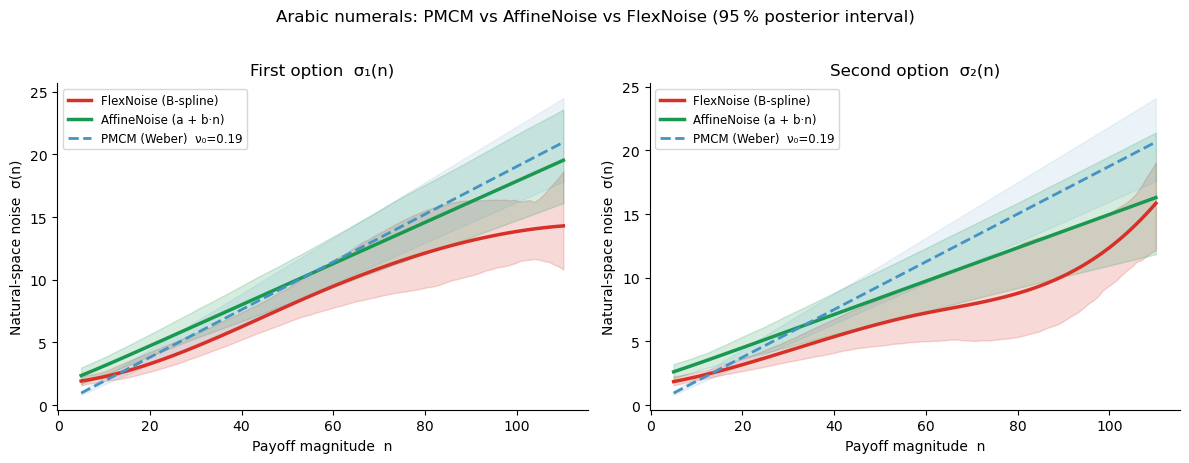

In [14]:
sd_curves = model_flex.get_sd_curve(idata=idata_flex, variable='both',
                                     group=True, data=df_sym.reset_index())
sd_curves_aff_sym = model_affine.get_sd_curve(idata=idata_affine, variable='both',
                                                group=True, data=df_sym.reset_index())
nu1_pmcm = idata_pmcm.posterior['n1_evidence_sd_mu'].values.ravel()
nu2_pmcm = idata_pmcm.posterior['n2_evidence_sd_mu'].values.ravel()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
colors = {'flex': '#d73027', 'affine': '#1a9850', 'pmcm': '#4393c3'}

for ax, (var_col, nu_pmcm_samp, title) in zip(
        axes,
        [('n1_evidence_sd', nu1_pmcm, 'First option  σ₁(n)'),
         ('n2_evidence_sd', nu2_pmcm, 'Second option  σ₂(n)')]):
    # FlexNoise
    grp = sd_curves.groupby(level='x')[var_col]
    x_vals = grp.mean().index.values
    ax.fill_between(x_vals, grp.quantile(0.025).values, grp.quantile(0.975).values,
                    alpha=.18, color=colors['flex'])
    ax.plot(x_vals, grp.mean().values, lw=2.5, color=colors['flex'], label='FlexNoise (B-spline)')
    # AffineNoise
    grp_a = sd_curves_aff_sym.groupby(level='x')[var_col]
    x_a = grp_a.mean().index.values
    ax.fill_between(x_a, grp_a.quantile(0.025).values, grp_a.quantile(0.975).values,
                    alpha=.18, color=colors['affine'])
    ax.plot(x_a, grp_a.mean().values, lw=2.5, color=colors['affine'], label='AffineNoise (a + b·n)')
    # PMCM reference
    nu0 = nu_pmcm_samp.mean()
    ax.plot(x_vals, nu0 * x_vals, ls='--', lw=2, color=colors['pmcm'],
            label=f'PMCM (Weber)  ν₀={nu0:.2f}')
    ax.fill_between(x_vals,
                    np.percentile(nu_pmcm_samp, 2.5) * x_vals,
                    np.percentile(nu_pmcm_samp, 97.5) * x_vals,
                    alpha=.10, color=colors['pmcm'])
    ax.set_xlabel('Payoff magnitude  n')
    ax.set_ylabel('Natural-space noise  σ(n)')
    ax.set_title(title); ax.legend(fontsize=8.5); sns.despine(ax=ax)

plt.suptitle('Arabic numerals: PMCM vs AffineNoise vs FlexNoise (95 % posterior interval)',
             fontsize=12, y=1.02)
plt.tight_layout()

## Posterior predictive comparison (Arabic numerals)

We overlay both models' predictions against the observed presentation-order
× stake-size pattern — the same diagnostic used in lesson 3.

Sampling: [ll_bernoulli]


Output()

Sampling: [ll_bernoulli]


Output()

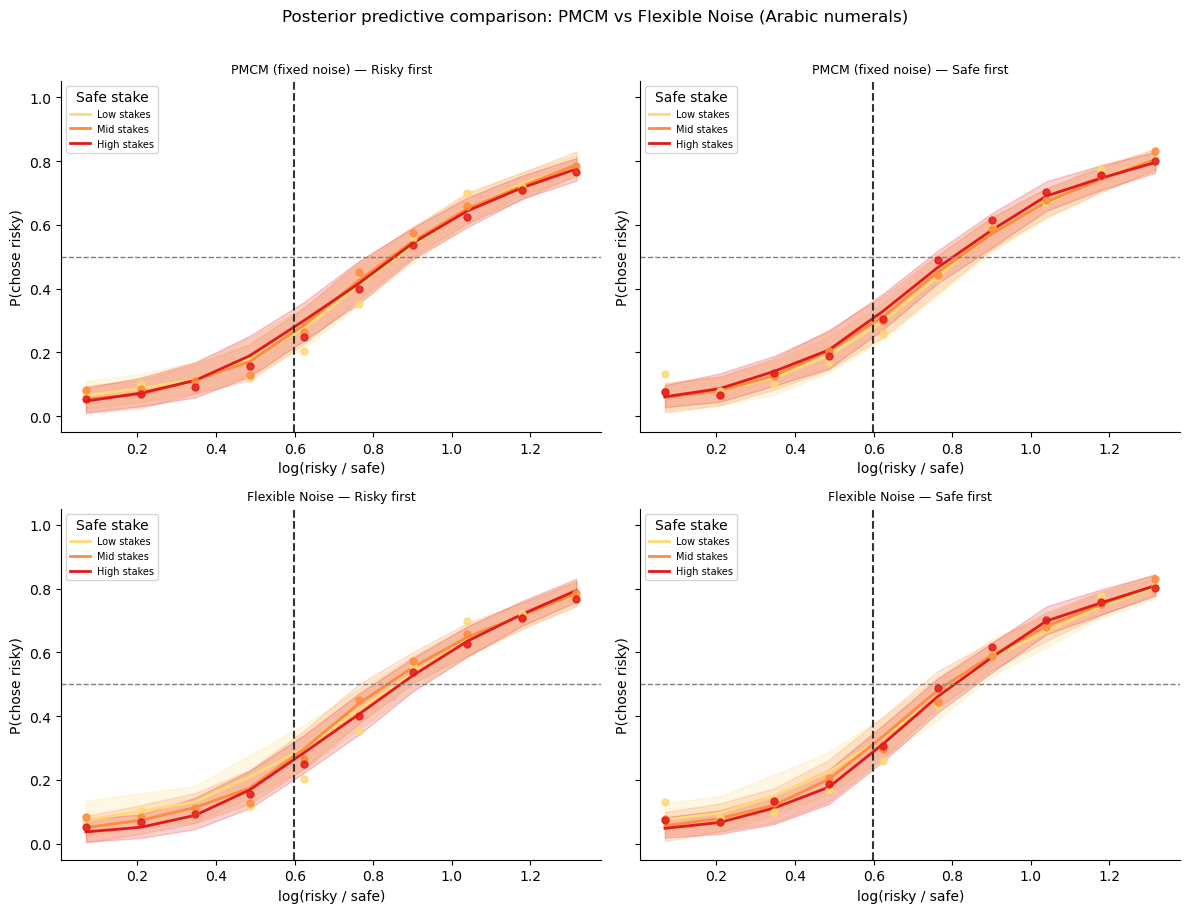

In [15]:
from bauer.utils import summarize_ppc_group
stake_pal = dict(zip(['Low stakes', 'Mid stakes', 'High stakes'], sns.color_palette('YlOrRd', 3)))

def add_model_ppc(df_orig, df_prepped, model, idata, model_name):
    """Two-step PPC via summarize_ppc_group."""
    ppc_df  = model.ppc(df_orig, idata, var_names=['ll_bernoulli'])
    ppc_ll  = ppc_df.xs('ll_bernoulli', level='variable')
    sample_cols = ppc_ll.columns.tolist()

    ppc_flat = ppc_ll.reset_index()
    risky_first = (ppc_flat['p1'] == 0.55)
    ppc_flat[sample_cols] = np.where(
        risky_first.values[:, None],
        1 - ppc_flat[sample_cols].values,
        ppc_flat[sample_cols].values
    )
    ppc_flat['order'] = np.where(risky_first, 'Risky first', 'Safe first')
    log_ratio = np.log(
        np.where(risky_first, ppc_flat['n1'], ppc_flat['n2']) /
        np.where(risky_first, ppc_flat['n2'], ppc_flat['n1']))
    ppc_flat['log_ratio_bin'] = (pd.cut(pd.Series(log_ratio), bins=10)
                                   .map(lambda x: x.mid).astype(float).values)
    n_safe = np.where(risky_first, ppc_flat['n2'], ppc_flat['n1'])
    ppc_flat['n_safe_bin'] = pd.qcut(n_safe, q=3,
                                      labels=['Low stakes', 'Mid stakes', 'High stakes'])

    result = summarize_ppc_group(ppc_flat,
                                  condition_cols=['order', 'n_safe_bin', 'log_ratio_bin'])
    return result.rename(columns={'p_predicted': 'p_mean',
                                   'hdi025': 'p_lo', 'hdi975': 'p_hi'}).reset_index()


def plot_ppc_row(df_pred, df_obs, model_name, axes_row):
    hue_order = ['Low stakes', 'Mid stakes', 'High stakes']
    for ax, order_val in zip(axes_row, ['Risky first', 'Safe first']):
        pred = df_pred[df_pred['order'] == order_val]
        obs  = df_obs[df_obs['order']   == order_val]
        for sbin in hue_order:
            p = pred[pred['n_safe_bin'] == sbin]
            o = obs[obs['n_safe_bin']   == sbin]
            if len(o) == 0:
                continue
            c = stake_pal[sbin]
            ax.fill_between(p['log_ratio_bin'], p['p_lo'], p['p_hi'], color=c, alpha=.2)
            ax.plot(p['log_ratio_bin'], p['p_mean'], color=c, lw=2, label=sbin)
            ax.scatter(o['log_ratio_bin'], o['chose_risky'],
                       color=c, s=25, zorder=5, alpha=.85)
        ax.axhline(.5, ls='--', c='gray', lw=1)
        ax.axvline(np.log(1/.55), ls='--', c='#333333', lw=1.5)
        ax.set_ylim(-.05, 1.05)
        ax.set_title(f'{model_name} — {order_val}', fontsize=9)
        ax.set_xlabel('log(risky / safe)'); ax.set_ylabel('P(chose risky)')
        ax.legend(title='Safe stake', fontsize=7, loc='upper left')
        sns.despine(ax=ax)


obs_sym_l4 = (df_sym_p
              .groupby(['subject', 'order', 'n_safe_bin', 'log_ratio_bin'])['chose_risky']
              .mean()
              .groupby(['order', 'n_safe_bin', 'log_ratio_bin']).mean()
              .reset_index())

fig, axes = plt.subplots(2, 2, figsize=(12, 9), sharey=True)
for (mdl, idat, name), row in zip(
        [(model_pmcm, idata_pmcm, 'PMCM (fixed noise)'),
         (model_flex, idata_flex, 'Flexible Noise')],
        axes):
    df_pred = add_model_ppc(df_sym, df_sym_p, mdl, idat, name)
    plot_ppc_row(df_pred, obs_sym_l4, name, row)

plt.suptitle('Posterior predictive comparison: PMCM vs Flexible Noise (Arabic numerals)',
             fontsize=12, y=1.01)
plt.tight_layout()

### Model comparison: PMCM vs AffineNoise vs FlexNoise (Arabic numerals)

The same three-way ELPD comparison for the risk models.

In [16]:
# ELPD comparison — Arabic numerals risky choice (3-way)
compare_sym = az.compare({'PMCM (Weber)':   idata_pmcm,
                           'AffineNoise':    idata_affine,
                           'FlexNoise':      idata_flex})
print(compare_sym[['elpd_loo', 'p_loo', 'elpd_diff', 'dse', 'warning']].to_string())

                 elpd_loo       p_loo  elpd_diff        dse  warning
FlexNoise    -5255.137017  358.592403   0.000000   0.000000     True
PMCM (Weber) -5265.285102  248.825810  10.148085  21.323564     True
AffineNoise  -5289.984210  305.939075  34.847193  16.043618     True


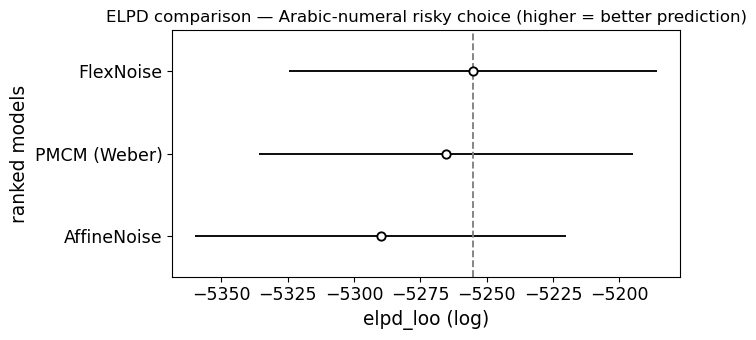

In [17]:
ax = az.plot_compare(compare_sym, figsize=(7, 3.5))
ax.set_title('ELPD comparison — Arabic-numeral risky choice (higher = better prediction)')
plt.tight_layout()

In [18]:
# ── Interpret the Arabic-numeral ELPD result (3-way) ─────────────────────────
print("ELPD ranking (Arabic numerals):")
print(compare_sym[['elpd_loo', 'p_loo', 'elpd_diff', 'dse', 'warning']].to_string())
print()

for i in range(1, len(compare_sym)):
    name = compare_sym.index[i]
    diff = compare_sym['elpd_diff'].iloc[i]
    dse  = compare_sym['dse'].iloc[i]
    ratio = abs(diff) / dse if dse > 0 else float('inf')
    winner = compare_sym.index[0]
    verdict = "distinguishable" if ratio > 2 else "NOT distinguishable"
    print(f"  {winner} vs {name}:  DELTA_ELPD = {diff:.1f},  SE = {dse:.1f},  "
          f"|ratio| = {ratio:.1f}  ->  {verdict}")

if 'AffineNoise' in compare_sym.index and 'FlexNoise' in compare_sym.index:
    aff_elpd = compare_sym.loc['AffineNoise', 'elpd_loo']
    flex_elpd = compare_sym.loc['FlexNoise', 'elpd_loo']
    print(f"\nAffineNoise ELPD: {aff_elpd:.1f},  FlexNoise ELPD: {flex_elpd:.1f}")
    if abs(aff_elpd - flex_elpd) < 10:
        print("-> Affine noise captures most of the FlexNoise advantage (if any).")
    else:
        print("-> Genuine nonlinearity in the noise function may be needed.")

ELPD ranking (Arabic numerals):
                 elpd_loo       p_loo  elpd_diff        dse  warning
FlexNoise    -5255.137017  358.592403   0.000000   0.000000     True
PMCM (Weber) -5265.285102  248.825810  10.148085  21.323564     True
AffineNoise  -5289.984210  305.939075  34.847193  16.043618     True

  FlexNoise vs PMCM (Weber):  DELTA_ELPD = 10.1,  SE = 21.3,  |ratio| = 0.5  ->  NOT distinguishable
  FlexNoise vs AffineNoise:  DELTA_ELPD = 34.8,  SE = 16.0,  |ratio| = 2.2  ->  distinguishable

AffineNoise ELPD: -5290.0,  FlexNoise ELPD: -5255.1
-> Genuine nonlinearity in the noise function may be needed.


## Take-aways

**What the ELPD actually tells us in this dataset:**

- **Dot arrays (Garcia et al. 2022):** the flexible noise model wins with
  $|\Delta\text{ELPD}| / \text{SE} \approx 3$, so the data *do* discriminate between the
  two — the MCM's strictly linear noise curve is not quite right.  The recovered
  $\nu(n)$ is roughly linear but deviates, suggesting a mild departure from perfect
  Weber's law in perceptual dot-array numerosity.
- **Arabic numerals (de Hollander et al., 2024, bioRxiv):** $|\Delta\text{ELPD}| / \text{SE} < 2$,
  so there is *no statistically distinguishable difference* in this dataset.  Weber's law
  (PMCM) is adequate for symbolic numbers here.  This may seem counterintuitive — but
  with only ~250 trials per subject, the data are simply not powerful enough to detect
  the kind of moderate deviations a flexible spline can pick up.

**Methodological take-aways:**

- The ELPD comparison gives a principled answer where visual inspection of noise curves
  cannot: $|\Delta\text{ELPD}| / \text{SE} > 2$ is a reasonable threshold for claiming
  the models are distinguishable.
- Rhat and ESS warnings in these notebooks reflect the deliberately short chain settings
  (draws=200, tune=200) chosen for speed.  For real analyses use at least draws=1000,
  tune=1000.
- Sampling with `idata_kwargs={{'log_likelihood': True}}` is all that is needed to
  unlock `az.compare` — bauer handles everything else.